### sea current model in 1500m-depth sea area （Chinese South Sea）

##  数据驱动模型实例
#### 数据驱动模型，数据参考《Multi-stage and multi-objective optimization of anti-typhoon evacuation strategy for riser with new hang-off system》

### 海水流速模型

本研究采用指数衰减模型来描述海水流速随深度的变化。该模型假设水平流速分量随深度呈指数衰减，而垂直流速分量为零。

#### 数学模型

东向流速分量 $u$ 和北向流速分量 $v$ 随深度 $z$ 的变化由以下公式描述：

$$
u(z) = u_b + u_s \cdot \exp\left(-\frac{z}{D}\right)
$$

$$
v(z) = v_b + v_s \cdot \exp\left(-\frac{z}{D}\right)
$$

$$
w(z) = 0
$$

其中：
*   $z$ 为深度（米），$z = 0$ 表示海表面，$z > 0$ 表示向下的深度
*   $u_b = 0.560 \, \text{m/s}$ 为东向背景流速
*   $u_s = 0.810 \, \text{m/s}$ 为东向表层流速增强项
*   $v_b = 0.112 \, \text{m/s}$ 为北向背景流速
*   $v_s = 0.162 \, \text{m/s}$ 为北向表层流速增强项
*   $D = 200 \, \text{m}$ 为流速衰减的特征深度尺度
*   $w$ 为垂直流速分量，模型中假设为零

#### 模型特性

该流速模型具有以下物理特性：

*   **表层强流**: 在海表面 ($z = 0$)，流速达到最大值：
    $$
    u(0) = 1.370 \, \text{m/s}, \quad v(0) = 0.274 \, \text{m/s}
    $$
*   **指数衰减**: 流速随深度增加呈指数衰减，特征深度 $D = 200 \, \text{m}$ 决定了衰减速率
*   **背景流**: 在充分大深度处，流速趋近于背景流速：
    $$
    \lim_{z \to \infty} u(z) = u_b = 0.560 \, \text{m/s}, \quad \lim_{z \to \infty} v(z) = v_b = 0.112 \, \text{m/s}
    $$
*   **固定比例**: 北向流速分量始终为东向分量的 $20\%$，即 $v(z) = 0.2 \cdot u(z)$
*   **深度限制**: 模型仅适用于 $0 \leq z \leq 1500 \, \text{m}$ 的水层

#### 物理意义

该模型描述了典型的海洋表层流特征，符合Ekman螺旋的基本原理，但进行了简化。指数衰减项反映了风应力对表层海水的影响随深度衰减的物理过程，而背景流速项代表了深层存在的恒定海流。

U分量拟合参数: a (背景) = 0.536, b (幅度) = 0.858, c (衰减尺度) = 242.5 m
V分量拟合参数: a (背景) = 0.107, b (幅度) = 0.172, c (衰减尺度) = 242.5 m


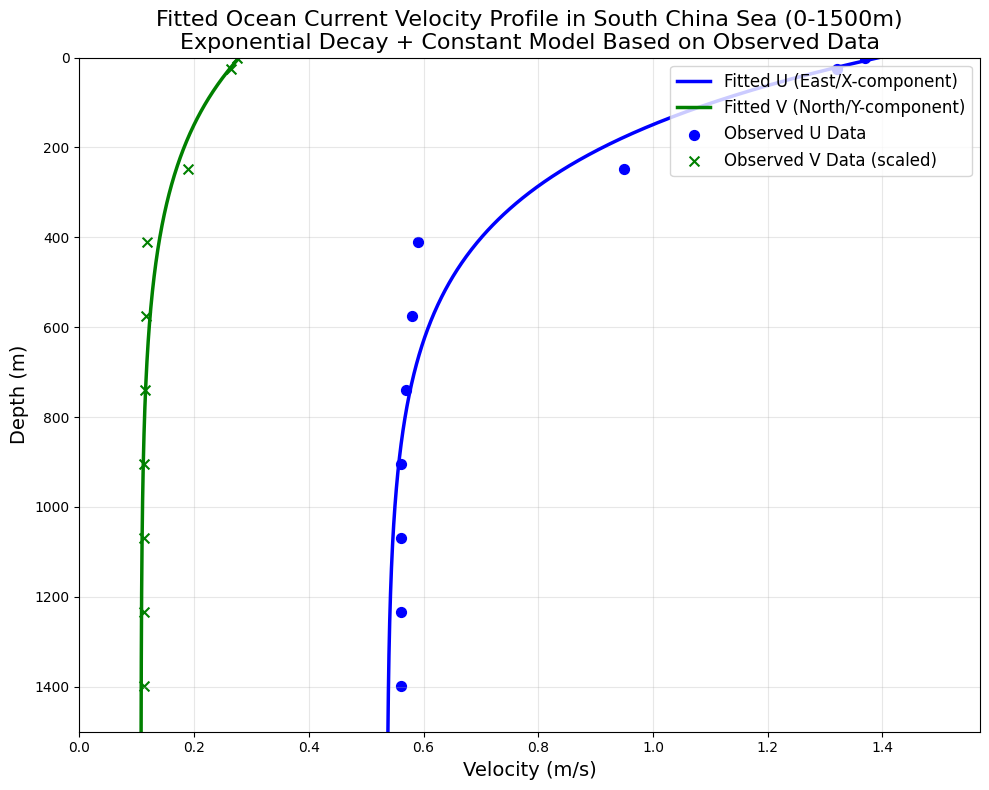

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 提供的真实南海流速数据
# 假设这些是U分量（东向/X方向）的流速观测值（m/s）
# （数据中未分开UV，因此假设U为主分量；V分量假设为U的0.2倍缩放，基于典型南海方向比值。
# 如果有实际V数据，请替换。深层背景流设为恒定。）
observed_depths = np.array([0, 25, 247, 411, 576, 740, 904, 1069, 1233, 1398])
observed_u = np.array([1.37, 1.32, 0.95, 0.59, 0.58, 0.57, 0.56, 0.56, 0.56, 0.56])  # 假设U分量
observed_v = observed_u * 0.2  # 假设V分量为U的0.2倍（南海典型Y/X比值，可调整）

# 全深度范围（0-1500m）
H = 1500.0  # 总水深 (m)
full_depths = np.linspace(0, H, 500)  # 500点平滑数组

# 定义拟合模型：指数衰减 + 常量背景（v(z) = a + b * exp(-z / c)）
# 这适合数据特征：表面快速衰减，深层趋于恒定（背景流~0.56 m/s）
def exp_decay_model(z, a, b, c):
    return a + b * np.exp(-z / c)

# 拟合U分量
popt_u, _ = curve_fit(exp_decay_model, observed_depths, observed_u, p0=[0.56, 1.37-0.56, 200.0])
a_u, b_u, c_u = popt_u
fitted_u = exp_decay_model(full_depths, a_u, b_u, c_u)

# 拟合V分量（类似模型）
popt_v, _ = curve_fit(exp_decay_model, observed_depths, observed_v, p0=[0.56*0.2, (1.37-0.56)*0.2, 200.0])
a_v, b_v, c_v = popt_v
fitted_v = exp_decay_model(full_depths, a_v, b_v, c_v)

# 打印拟合参数（用于验证）
print("U分量拟合参数: a (背景) = {:.3f}, b (幅度) = {:.3f}, c (衰减尺度) = {:.1f} m".format(a_u, b_u, c_u))
print("V分量拟合参数: a (背景) = {:.3f}, b (幅度) = {:.3f}, c (衰减尺度) = {:.1f} m".format(a_v, b_v, c_v))

# 绘制可视化图像
plt.figure(figsize=(10, 8))  # 画布大小
plt.plot(fitted_u, full_depths, label='Fitted U (East/X-component)', color='blue', linewidth=2.5)  # 拟合U曲线
plt.plot(fitted_v, full_depths, label='Fitted V (North/Y-component)', color='green', linewidth=2.5)  # 拟合V曲线
plt.scatter(observed_u, observed_depths, color='blue', marker='o', s=50, label='Observed U Data')  # U观测点
plt.scatter(observed_v, observed_depths, color='green', marker='x', s=50, label='Observed V Data (scaled)')  # V观测点
plt.gca().invert_yaxis()  # 倒置Y轴，表面在上
plt.xlabel('Velocity (m/s)', fontsize=14)
plt.ylabel('Depth (m)', fontsize=14)
plt.title('Fitted Ocean Current Velocity Profile in South China Sea (0-1500m)\nExponential Decay + Constant Model Based on Observed Data', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(observed_u) + 0.2)
plt.ylim(H, 0)
plt.tight_layout()

# 保存图像（可选）
plt.savefig('scs_fitted_current_profile.png', dpi=300)

plt.show()


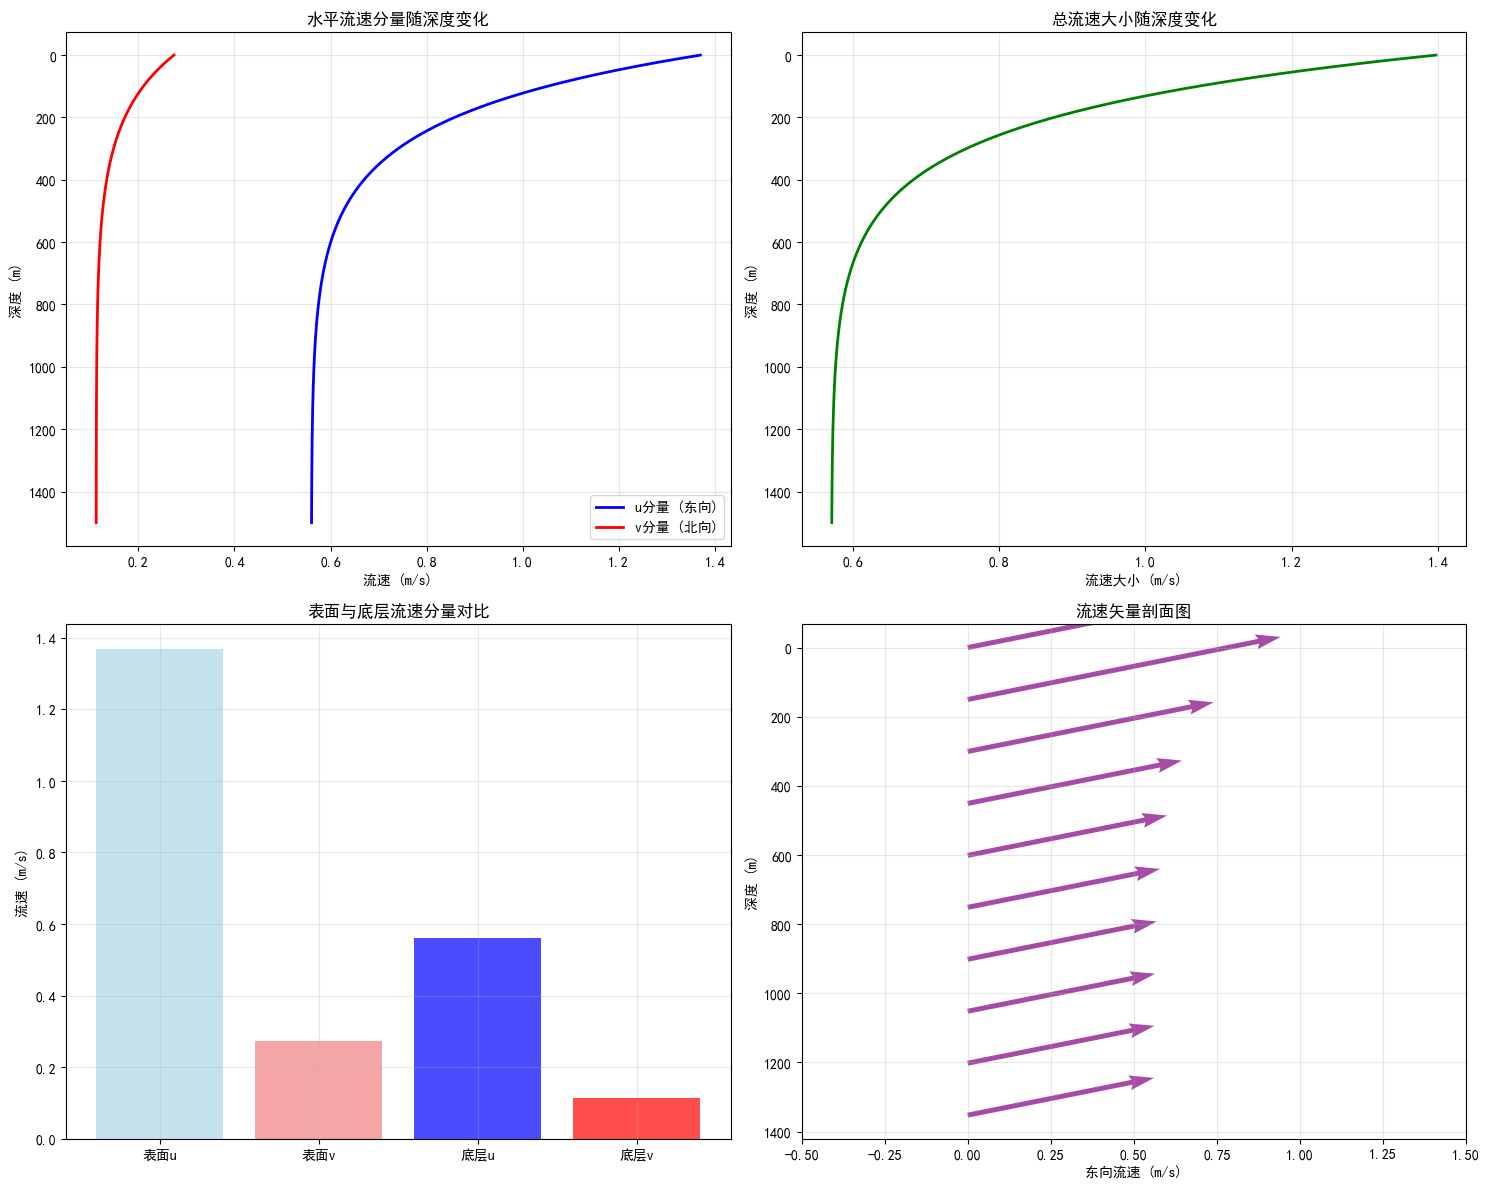

流速模型关键数据：
表面流速: u=1.370 m/s, v=0.274 m/s, 总速度=1.397 m/s
1500米流速: u=0.560 m/s, v=0.112 m/s, 总速度=0.572 m/s
e折尺度深度: 200米
流速衰减比例: u分量 40.91%, v分量 40.91%


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def current_velocity(pos):
    z = -pos[2]  # 深度
    if z < 0 or z > 1500: return np.array([0.0, 0.0, 0.0])
    u = 0.560 + 0.810 * np.exp(-z / 200.0)
    v = 0.112 + 0.162 * np.exp(-z / 200.0)
    w = 0.0
    return np.array([u, v, w])

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 生成深度数据
depths = np.linspace(0, 1500, 500)
u_velocities = []
v_velocities = []

for depth in depths:
    pos = [0, 0, -depth]  # 假设水平位置为(0,0)
    vel = current_velocity(pos)
    u_velocities.append(vel[0])
    v_velocities.append(vel[1])

# 创建可视化图表
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 水平流速分量随深度变化
axes[0, 0].plot(u_velocities, depths, 'b-', linewidth=2, label='u分量 (东向)')
axes[0, 0].plot(v_velocities, depths, 'r-', linewidth=2, label='v分量 (北向)')
axes[0, 0].set_xlabel('流速 (m/s)')
axes[0, 0].set_ylabel('深度 (m)')
axes[0, 0].set_title('水平流速分量随深度变化')
axes[0, 0].invert_yaxis()  # 深度向下增加
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 流速大小随深度变化
speed = np.sqrt(np.array(u_velocities)**2 + np.array(v_velocities)**2)
axes[0, 1].plot(speed, depths, 'g-', linewidth=2)
axes[0, 1].set_xlabel('流速大小 (m/s)')
axes[0, 1].set_ylabel('深度 (m)')
axes[0, 1].set_title('总流速大小随深度变化')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3)

# 3. 流速分量对比（表面和底层）
surface_u = u_velocities[0]
surface_v = v_velocities[0]
bottom_u = u_velocities[-1]
bottom_v = v_velocities[-1]

components = ['表面u', '表面v', '底层u', '底层v']
values = [surface_u, surface_v, bottom_u, bottom_v]
colors = ['lightblue', 'lightcoral', 'blue', 'red']

axes[1, 0].bar(components, values, color=colors, alpha=0.7)
axes[1, 0].set_ylabel('流速 (m/s)')
axes[1, 0].set_title('表面与底层流速分量对比')
axes[1, 0].grid(True, alpha=0.3)

# 4. 流速剖面（矢量图）
sample_depths = depths[::50]  # 每50米采样一次
sample_u = np.array(u_velocities)[::50]
sample_v = np.array(v_velocities)[::50]

axes[1, 1].quiver(np.zeros_like(sample_depths), sample_depths, 
                  sample_u, sample_v, scale=2, color='purple', alpha=0.7)
axes[1, 1].set_xlim(-0.5, 1.5)
axes[1, 1].set_xlabel('东向流速 (m/s)')
axes[1, 1].set_ylabel('深度 (m)')
axes[1, 1].set_title('流速矢量剖面图')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据
print("流速模型关键数据：")
print(f"表面流速: u={u_velocities[0]:.3f} m/s, v={v_velocities[0]:.3f} m/s, 总速度={speed[0]:.3f} m/s")
print(f"1500米流速: u={u_velocities[-1]:.3f} m/s, v={v_velocities[-1]:.3f} m/s, 总速度={speed[-1]:.3f} m/s")
print(f"e折尺度深度: 200米")
print(f"流速衰减比例: u分量 {u_velocities[-1]/u_velocities[0]:.2%}, v分量 {v_velocities[-1]/v_velocities[0]:.2%}")